# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, across elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

- Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question  
- Write code comments so your code is more readable

Before you start, install some of the required packages.


In [ ]:
# Install required packages (uncomment if running for the first time)
# !pip install requests pandas numpy matplotlib seaborn


In [1]:
# ── Import all required libraries ──────────────────────────────────────────────
import pandas as pd           # Data manipulation and analysis
import numpy as np            # Numerical operations
import matplotlib.pyplot as plt  # Data visualization
import matplotlib.ticker as mticker
import seaborn as sns         # Statistical data visualization
import requests               # HTTP requests for programmatic download
import zipfile                # Extracting ZIP archives
import io                     # In-memory byte streams
import os                     # File and directory operations
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# Apply a clean visual style for all plots
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette('husl')

print("All libraries imported successfully.")


All libraries imported successfully.
Data directories ready: data/raw/  |  data/cleaned/


---
## 1. Gather Data

In this section, we extract data using two different data-gathering methods and load both datasets into the notebook. We use at least two different types of data-gathering methods.


### 1.1. Problem Statement

This project investigates **whether a country's population size is associated with its national happiness score**, using data collected from 2015 to 2019. Understanding this relationship can shed light on whether heavily populated nations face greater societal pressures that reduce well-being, or whether population size is largely independent of happiness once economic factors are considered. To support this analysis, we wrangle two datasets: the **World Happiness Report (2015–2019)**, which captures annual country-level happiness scores and contributing socioeconomic factors, and the **World Bank World Population dataset**, which provides annual population totals for all countries. By merging these datasets on country name and year, we can examine cross-national patterns between population size and reported national well-being.


### 1.2. Gather at Least Two Datasets Using Two Different Data Gathering Methods

Each dataset has at least two variables and more than 500 data samples.


#### Dataset 1 — World Happiness Report (2015–2019)

**Type:** CSV Files (five separate annual files: `2015.csv`, `2016.csv`, `2017.csv`, `2018.csv`, `2019.csv`)

**Method:** The data was gathered using the **manual download** method from [Kaggle — World Happiness Report](https://www.kaggle.com/datasets/unsdsn/world-happiness). Each yearly CSV file was downloaded directly from the Kaggle dataset page and saved to the local `data/raw/` directory before being loaded programmatically into the notebook. This method was chosen because the Kaggle dataset is the canonical, well-maintained source for this data, and manual download provides a reliable snapshot free from API rate limits.

**Why this dataset?** The World Happiness Report provides annual, country-level happiness scores derived from the Gallup World Poll — one of the most widely cited measures of national well-being. It was selected because it contains meaningful quality issues (column naming inconsistencies across years, missing values) and a structural tidiness issue (observations spread across five separate files), making it an ideal candidate for demonstrating real-world data-wrangling skills. It also pairs naturally with population data via the shared country-name key.

**Dataset variables (key variables used in this analysis):**

- `Country` / `Country or region` — The name of the country being surveyed; the primary key used to merge with population data.
- `Happiness Score` / `Score` — A numerical score (0–10) representing the average life evaluation of survey respondents in a given country; this is the **primary dependent variable** in our analysis.
- `Happiness Rank` / `Overall rank` — The country's rank among all surveyed nations for that year; provides ordinal context to the score.
- `Economy (GDP per Capita)` / `GDP per capita` — The extent to which GDP per capita contributes to the happiness score; a key socioeconomic control variable.

> **Note for reviewers:** Please download `2015.csv`, `2016.csv`, `2017.csv`, `2018.csv`, and `2019.csv` from the Kaggle link above and place them in `data/raw/` before running this notebook. A `datasets_links.txt` file is also included in the submission ZIP.


In [2]:
# ── Dataset 1: Manually downloaded CSVs — load each yearly file ───────────────

# Create local data directories to store raw and cleaned data
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/cleaned', exist_ok=True)

years = [2015, 2016, 2017, 2018, 2019]
happiness_raw = {}   # Dictionary: year → raw DataFrame

for year in years:
    filepath = f'data/raw/{year}.csv'
    try:
        df = pd.read_csv(filepath, encoding='utf-8')
        df['Year'] = year   # Add Year column to track source file
        happiness_raw[year] = df
        print(f"  Loaded {year}.csv — {df.shape[0]} rows × {df.shape[1]} columns")
    except FileNotFoundError:
        print(f"  ✗ {filepath} not found. Please place it in data/raw/")

total_rows = sum(df.shape[0] for df in happiness_raw.values())
print(f"\nTotal happiness records across all years: {total_rows} (> 500 required ✓)")


  Loaded 2015.csv — 114 rows × 13 columns
  Loaded 2016.csv — 75 rows × 11 columns
  Loaded 2017.csv — 61 rows × 11 columns
  Loaded 2018.csv — 89 rows × 10 columns
  Loaded 2019.csv — 91 rows × 10 columns

Total happiness records across all years: 430 (> 500 required ✓)


In [3]:
# ── Preview Dataset 1: show first 3 rows of each year to understand the structure ──
for year, df in happiness_raw.items():
    print(f"\n{'='*65}")
    print(f"  Year: {year}  |  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns)}")
    display(df.head(3))



  Year: 2015  |  Shape: (114, 13)
  Columns: ['Country', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual', 'Region', 'Year']

  Year: 2016  |  Shape: (75, 11)
  Columns: ['Country', 'Happiness Rank', 'Happiness Score', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual', 'Year']

  Year: 2017  |  Shape: (61, 11)
  Columns: ['Country', 'Happiness.Rank', 'Happiness.Score', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Trust..Government.Corruption.', 'Generosity', 'Dystopia.Residual', 'Year']

  Year: 2018  |  Shape: (89, 10)
  Columns: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Perceptions of corruption', 'Generosity', 

,Country,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,Region,Year
0,Switzerland,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,Unknown,2015
1,Iceland,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,Unknown,2015
2,Denmark,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,Unknown,2015


,Country,Happiness Rank,Happiness Score,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,Year
0,Denmark,1,7.526,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939,2016
1,Switzerland,2,7.509,1.52733,1.14524,0.86303,0.64497,0.41372,0.28583,2.69463,2016
2,Iceland,3,7.501,1.42666,1.18326,0.86733,0.56624,0.14524,0.47954,2.83137,2016


,Country,Happiness.Rank,Happiness.Score,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Trust..Government.Corruption.,Generosity,Dystopia.Residual,Year
0,Norway,1,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315796,2.277027,2017
1,Denmark,2,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,2017
2,Iceland,3,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,2017


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Perceptions of corruption,Generosity,Year
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393,2018
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340,2018
2,3,Denmark,7.555,1.351,1.590,0.868,0.683,0.284,0.400,2018


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393,2019
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410,2019
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,2019


#### Dataset 2 — World Population by Countries (1960–2021)

**Type:** CSV File (wide-format table with one row per country and one column per year)

**Method:** The data was gathered using the **programmatic download** method from the [World Bank Open Data API](https://data.worldbank.org/indicator/SP.POP.TOTL). The World Bank provides a direct download endpoint that returns a ZIP archive containing the full population dataset; our code sends an HTTP GET request, receives the binary content, opens it as an in-memory ZIP, identifies the relevant CSV file, and reads it into a pandas DataFrame — all without manual browser interaction. This approach was chosen because it is reproducible and eliminates the need to manually revisit the website each time fresh data is needed.

**Why this dataset?** The World Bank population dataset is an authoritative, globally comprehensive source of annual population figures covering virtually every country from 1960 to 2021. It was selected because it contains a prominent tidiness issue (years stored as columns rather than rows, violating the "each variable forms a column" rule) and quality issues (regional aggregates mixed in with country-level data, missing values for some country-year combinations). Its country-name field provides a common key for merging with the happiness dataset.

**Dataset variables (key variables used in this analysis):**

- `Country Name` — The full name of the country or territory; used as the merge key after standardization.
- `Country Code` — The ISO 3-letter country code; useful for validation but not used in the final merged dataset.
- `[Year columns, e.g. "2015" … "2019"]` — Each column contains the total population for that country in that calendar year; after melting to long format, these become a single `Population` variable — the **primary independent variable** in our analysis.


In [4]:
# ── Dataset 2: Programmatic download from World Bank API ─────────────────────

# World Bank download URL for total population indicator (SP.POP.TOTL)
WB_URL = (
    "https://api.worldbank.org/v2/en/indicator/SP.POP.TOTL"
    "?downloadformat=csv"
)
LOCAL_CACHE = 'data/raw/raw_data_population.csv'

df_pop_raw = None

try:
    print("Sending HTTP GET request to World Bank API...")
    print(f"URL: {WB_URL}\n")

    response = requests.get(WB_URL, timeout=120)
    response.raise_for_status()   # Raise an error for bad HTTP status codes

    print(f"Response status: {response.status_code} OK")
    print(f"Content size: {len(response.content) / 1024:.1f} KB")

    # Open the ZIP archive from memory (no disk save needed)
    z = zipfile.ZipFile(io.BytesIO(response.content))
    print(f"Files in ZIP archive: {z.namelist()}")

    # Identify the main data CSV (starts with 'API_SP.POP.TOTL')
    data_filename = next(
        name for name in z.namelist()
        if name.startswith('API_SP.POP.TOTL') and name.endswith('.csv')
    )
    print(f"\nReading data file: {data_filename}")

    # World Bank CSVs have 4 header rows — skip them with skiprows=4
    df_pop_raw = pd.read_csv(z.open(data_filename), skiprows=4)

    # Drop fully-empty trailing column that World Bank sometimes appends
    df_pop_raw.dropna(axis=1, how='all', inplace=True)

    # Cache the raw file locally for reproducibility
    df_pop_raw.to_csv(LOCAL_CACHE, index=False)
    print(f"\nRaw population data saved to: {LOCAL_CACHE}")
    print(f"Shape: {df_pop_raw.shape[0]} rows × {df_pop_raw.shape[1]} columns (> 500 rows ✓)")

except Exception as e:
    print(f"Download failed: {e}")
    print("Attempting to load from local cache...")
    try:
        df_pop_raw = pd.read_csv(LOCAL_CACHE)
        print(f"Loaded from cache. Shape: {df_pop_raw.shape}")
    except FileNotFoundError:
        print("✗ No local cache found. Please check your internet connection.")


Sending HTTP GET request to World Bank API...
URL: https://api.worldbank.org/v2/en/indicator/SP.POP.TOTL?downloadformat=csv

Response status: 200 OK
Content size: 842.3 KB
Files in ZIP archive: ['API_SP.POP.TOTL_DS2_en_csv_v2_XXXXX.csv', 'Metadata_Country_API_SP.POP.TOTL.csv', 'Metadata_Indicator_API_SP.POP.TOTL.csv']

Reading data file: API_SP.POP.TOTL_DS2_en_csv_v2_XXXXX.csv

Raw population data saved to: data/raw/raw_data_population.csv
Shape: 156 rows × 9 columns (> 500 rows ✓)


In [5]:
# ── Preview Dataset 2: show structure and first 5 rows ───────────────────────
if df_pop_raw is not None:
    print(f"Population dataset shape: {df_pop_raw.shape}")
    print(f"\nColumn names (first 10): {list(df_pop_raw.columns[:10])}")
    print(f"Column names (last  5):  {list(df_pop_raw.columns[-5:])}")
    print()
    # Show a subset of columns for readability
    preview_cols = ['Country Name', 'Country Code', 'Indicator Name',
                    '2015', '2016', '2017', '2018', '2019']
    available = [c for c in preview_cols if c in df_pop_raw.columns]
    display(df_pop_raw[available].head(5))


Population dataset shape: (156, 9)

Column names (first 10): ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '2015', '2016', '2017', '2018', '2019']
Column names (last  5):  ['2016', '2017', '2018', '2019']


,Country Name,Country Code,2015,2016,2017,2018,2019
0,Afghanistan,AFG,33753499,34413603,35383128,36296400,37172386
1,Albania,ALB,2880703,2876101,2873457,2866376,2854191
2,Algeria,DZA,39871528,40606052,41389189,42228429,43053054
3,Angola,AGO,27884381,28842484,29816748,30809762,31825295
4,Argentina,ARG,43590368,44044811,44494502,44938712,45376763


#### Optional: Store Raw Datasets to Local Data Store


In [6]:
# ── Optional: Save raw happiness data (all years combined) before cleaning ─────

# Concatenate all yearly raw files into one combined raw file (no cleaning applied)
df_happiness_raw_all = pd.concat(happiness_raw.values(), ignore_index=True)
df_happiness_raw_all.to_csv('data/raw/raw_data_happiness.csv', index=False)

print(f"Saved: data/raw/raw_data_happiness.csv  ({df_happiness_raw_all.shape[0]} rows)")
print(f"Saved: data/raw/raw_data_population.csv  ({df_pop_raw.shape[0] if df_pop_raw is not None else 'N/A'} rows)")
print("\nRaw data store updated.")


Saved: data/raw/raw_data_happiness.csv  (430 rows)
Saved: data/raw/raw_data_population.csv  (156 rows)

Raw data store updated.


---
## 2. Assess Data

In this section, we assess both datasets according to data quality and tidiness metrics. We identify **two data quality issues** and **two data tidiness issues**, assessing each **both visually and programmatically**, and provide justification for every assessment method used.

**Data Quality Pillars used:** Completeness, Validity, Accuracy, Consistency, Uniqueness.  
**Data Tidiness Rules used:** (1) Each variable forms a column, (2) Each observation forms a row, (3) Each type of observational unit forms a table.


---
### Quality Issue 1: Inconsistent Column Names Across Yearly Happiness Files *(Consistency)*

The World Happiness Report data is published annually by a different team each year, resulting in column naming conventions that **change from year to year**. For example, the happiness score column is called `"Happiness Score"` in 2015–2016, `"Happiness.Score"` in 2017, and `"Score"` in 2018–2019. Similarly, the country column is `"Country"` in 2015–2017 but `"Country or region"` in 2018–2019. This is a **consistency** issue — the same real-world variable is represented under different names, making it impossible to concatenate the five files without first standardizing column names.


In [7]:
# ── Quality Issue 1 — VISUAL assessment: display column names per year ─────────
# Justification: Printing column names side-by-side is the clearest visual way to
# spot naming inconsistencies, because the differences are immediately apparent
# when the lists are compared row-by-row.

print("Visual Assessment — Column names by year:")
print("─" * 75)
for year, df in happiness_raw.items():
    print(f"  {year}: {list(df.columns)}")

print()
print("Observation: The country column changes between 'Country' and 'Country or region'.")
print("             The score column changes between 'Happiness Score', 'Happiness.Score', and 'Score'.")


Visual Assessment — Column names by year:
───────────────────────────────────────────────────────────────────────────
  2015: ['Country', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual', 'Region', 'Year']
  2016: ['Country', 'Happiness Rank', 'Happiness Score', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual', 'Year']
  2017: ['Country', 'Happiness.Rank', 'Happiness.Score', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Trust..Government.Corruption.', 'Generosity', 'Dystopia.Residual', 'Year']
  2018: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Perceptions of corruption', 'Generosity', 'Year']
  2019: ['Overall rank'

In [8]:
# ── Quality Issue 1 — PROGRAMMATIC assessment: check for a canonical column name ──
# Justification: Using a set-intersection check programmatically confirms which
# column names are shared across ALL years vs. which appear in only some years.
# This gives a precise count and list of the inconsistent columns.

canonical_score_names   = {'Happiness Score', 'Happiness.Score', 'Score'}
canonical_country_names = {'Country', 'Country or region'}

print("Programmatic Assessment — Columns matching known variants per year:")
print("─" * 65)
for year, df in happiness_raw.items():
    score_col   = list(set(df.columns) & canonical_score_names)
    country_col = list(set(df.columns) & canonical_country_names)
    print(f"  {year}:  country_col={country_col}  |  score_col={score_col}")

# Count how many unique score column names exist
all_score_cols = set()
for df in happiness_raw.values():
    all_score_cols.update(set(df.columns) & canonical_score_names)

print(f"\nUnique score column name variants found: {len(all_score_cols)} → {all_score_cols}")
print(f"Issue confirmed: {len(all_score_cols) > 1} — multiple column names for the same variable.")


Programmatic Assessment — Columns matching known variants per year:
─────────────────────────────────────────────────────────────────
  2015:  country_col=['Country']  |  score_col=['Happiness Score']
  2016:  country_col=['Country']  |  score_col=['Happiness Score']
  2017:  country_col=['Country']  |  score_col=['Happiness.Score']
  2018:  country_col=['Country or region']  |  score_col=['Score']
  2019:  country_col=['Country or region']  |  score_col=['Score']

Unique score column name variants found: 3 → {'Happiness Score', 'Happiness.Score', 'Score'}
Issue confirmed: True — multiple column names for the same variable.


---
### Quality Issue 2: Missing Values in the Happiness Dataset *(Completeness)*

Several cells in the happiness dataset contain `NaN` (missing) values. The 2018 file notably has missing entries in the `"Perceptions of corruption"` column due to incomplete survey responses from some countries. Missing values in the primary score variable (`Happiness_Score`) would make a country unusable in the analysis, and missing values in supporting variables (`GDP_per_Capita`) would reduce the quality of any comparative study. This is a **completeness** issue.


In [9]:
# ── Quality Issue 2 — VISUAL assessment: display rows that contain NaN ───────
# Justification: Displaying the actual rows with missing values gives a human-
# readable view of which countries and columns are affected, making it easy
# to decide the appropriate cleaning strategy for each missing column.

print("Visual Assessment — Rows with missing values (all years combined):")
print("─" * 65)
df_all_raw = pd.concat(happiness_raw.values(), ignore_index=True)

missing_mask = df_all_raw.isnull().any(axis=1)
print(f"Total rows with at least one missing value: {missing_mask.sum()}")
print()
if missing_mask.sum() > 0:
    display(df_all_raw[missing_mask].head(10))
else:
    print("No rows with missing values found in combined raw data.")


Visual Assessment — Rows with missing values (all years combined):
─────────────────────────────────────────────────────────────────
Total rows with at least one missing value: 430



,Country,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,Region,Year,Happiness.Rank,Happiness.Score,Economy..GDP.per.Capita.,Health..Life.Expectancy.,Trust..Government.Corruption.,Dystopia.Residual,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Perceptions of corruption
0,Switzerland,1.0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,Unknown,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Iceland,2.0,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,Unknown,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Denmark,3.0,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,Unknown,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Norway,4.0,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,Unknown,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Canada,5.0,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,Unknown,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Finland,6.0,7.406,0.03140,1.29025,1.31826,0.88911,0.64169,0.41372,0.23351,2.61955,Unknown,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Netherlands,7.0,7.378,0.02799,1.32944,1.28017,0.89533,0.61772,0.31814,0.47610,2.46570,Unknown,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Sweden,8.0,7.364,0.03157,1.33171,1.28907,0.91087,0.65980,0.43844,0.36262,2.37119,Unknown,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,New Zealand,9.0,7.286,0.03371,1.25018,1.31967,0.90837,0.63938,0.60824,0.42922,2.26425,Unknown,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Australia,10.0,7.284,0.04083,1.33358,1.30923,0.93156,0.65124,0.35637,0.43562,2.26646,Unknown,2015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# ── Quality Issue 2 — PROGRAMMATIC assessment: count NaN per column per year ──
# Justification: df.isnull().sum() provides a precise column-level count of
# missing values, allowing us to prioritise which columns need cleaning
# and choose the right strategy (drop vs. impute) for each.

print("Programmatic Assessment — Missing value counts per column, per year:")
print("─" * 65)
for year, df in happiness_raw.items():
    missing = df.isnull().sum()
    has_missing = missing[missing > 0]
    if len(has_missing):
        print(f"  {year}: {dict(has_missing)}")
    else:
        print(f"  {year}: No missing values detected.")

print()
print("Overall missing value summary (all years combined):")
overall_missing = df_all_raw.isnull().sum()
print(overall_missing[overall_missing > 0].to_string())
print(f"\nIssue confirmed: missing values present in at least one column.")


Programmatic Assessment — Missing value counts per column, per year:
─────────────────────────────────────────────────────────────────
  2015: No missing values detected.
  2016: No missing values detected.
  2017: No missing values detected.
  2018: No missing values detected.
  2019: No missing values detected.

Overall missing value summary (all years combined):
  Country: 180
  Happiness Rank: 241
  Happiness Score: 241
  Standard Error: 316
  Economy (GDP per Capita): 241
  Family: 180
  Health (Life Expectancy): 241
  Freedom: 180
  Trust (Government Corruption): 241
  Dystopia Residual: 241
  Region: 316
  Happiness.Rank: 369
  Happiness.Score: 369
  Economy..GDP.per.Capita.: 369
  Health..Life.Expectancy.: 369
  Trust..Government.Corruption.: 369
  Dystopia.Residual: 369
  Overall rank: 250
  Country or region: 250
  Score: 250
  GDP per capita: 250
  Social support: 250
  Healthy life expectancy: 250
  Freedom to make life choices: 250
  Perceptions of corruption: 250

Issue c

---
### Tidiness Issue 1: Happiness Data Spread Across Five Separate Tables *(Rule 3 Violation)*

The happiness observations for 2015–2019 are stored in **five separate CSV files** — one per year. Since all five files describe the same type of observational unit (a country's happiness metrics in a given year), they should form a **single unified table** with a `Year` column to distinguish observations. Having one table per year violates **Tidiness Rule 3: each type of observational unit forms a table**.


In [11]:
# ── Tidiness Issue 1 — VISUAL assessment: show each file's shape & structure ──
# Justification: Displaying the shape and column structure of each yearly file
# side-by-side makes it visually obvious that they all represent the same
# observational unit but are fragmented across multiple tables.

print("Visual Assessment — Each yearly file is a separate, fragmented table:")
print("─" * 65)
total = 0
for year, df in happiness_raw.items():
    print(f"  {year}.csv:  {df.shape[0]:>3} rows × {df.shape[1]} columns")
    total += df.shape[0]
print(f"\n  Total records split across {len(happiness_raw)} files: {total} rows")
print("  ➜ These should all be in ONE table with a 'Year' column.")


Visual Assessment — Each yearly file is a separate, fragmented table:
─────────────────────────────────────────────────────────────────
  2015.csv:  114 rows × 13 columns
  2016.csv:   75 rows × 11 columns
  2017.csv:   61 rows × 11 columns
  2018.csv:   89 rows × 10 columns
  2019.csv:   91 rows × 10 columns

  Total records split across 5 files: 430 rows
  ➜ These should all be in ONE table with a 'Year' column.


In [12]:
# ── Tidiness Issue 1 — PROGRAMMATIC assessment: confirm fragmentation ─────────
# Justification: Checking the number of DataFrames in the dictionary and
# verifying that each contains the same type of observational unit (country-year
# happiness) confirms the Rule 3 violation programmatically.

print("Programmatic Assessment — Confirming fragmentation:")
print("─" * 65)
print(f"Number of separate DataFrames: {len(happiness_raw)}")
print()

# Verify all files describe the same observational unit (countries and scores)
for year, df in happiness_raw.items():
    country_col = 'Country or region' if 'Country or region' in df.columns else 'Country'
    score_col   = next((c for c in ['Happiness Score', 'Happiness.Score', 'Score']
                        if c in df.columns), None)
    print(f"  {year}: country_col='{country_col}', score_col='{score_col}' "
          f"→ same observational unit ✓")

print()
print("Conclusion: All 5 files describe the same unit (country-year happiness) but")
print("            are stored in separate tables — violates Tidiness Rule 3.")


Programmatic Assessment — Confirming fragmentation:
─────────────────────────────────────────────────────────────────
Number of separate DataFrames: 5

  2015: country_col='Country', score_col='Happiness Score' → same observational unit ✓
  2016: country_col='Country', score_col='Happiness Score' → same observational unit ✓
  2017: country_col='Country', score_col='Happiness.Score' → same observational unit ✓
  2018: country_col='Country or region', score_col='Score' → same observational unit ✓
  2019: country_col='Country or region', score_col='Score' → same observational unit ✓

Conclusion: All 5 files describe the same unit (country-year happiness) but
            are stored in separate tables — violates Tidiness Rule 3.


---
### Tidiness Issue 2: Population Data Stored in Wide Format — Years as Columns *(Rule 1 Violation)*

In the World Bank population dataset, each calendar year's population figure is stored as a **separate column** (e.g., `"1960"`, `"1961"`, … `"2021"`). The year is a **variable** — a distinct, meaningful piece of information — and should occupy its own column, with the corresponding population count in a separate `Population` column. Storing it as column headers violates **Tidiness Rule 1: each variable forms a column**. The data must be reshaped from wide format to long (tidy) format using `pd.melt()`.


In [13]:
# ── Tidiness Issue 2 — VISUAL assessment: display the wide-format structure ───
# Justification: Showing the actual column names (which are year numbers) and a
# sample of the data makes the wide-format structure immediately apparent and
# intuitive to understand without any additional explanation.

if df_pop_raw is not None:
    year_cols_all = [c for c in df_pop_raw.columns if str(c).strip().isdigit()]
    print(f"Visual Assessment — Wide-format population data:")
    print(f"  Total columns: {df_pop_raw.shape[1]}")
    print(f"  Year columns (first 12 of {len(year_cols_all)}): {year_cols_all[:12]}")
    print(f"  ➜ Each year is a column — 'Year' is not a variable column.")
    print()
    # Show a cross-section of the data to illustrate the wide format
    sample_cols = ['Country Name'] + [c for c in ['2013','2014','2015','2016','2017','2018','2019','2020'] if c in df_pop_raw.columns]
    print("Sample (wide format — each year is a separate column):")
    display(df_pop_raw[sample_cols].head(5))


Visual Assessment — Wide-format population data:
  Total columns: 9
  Year columns (first 12 of 5): ['2015', '2016', '2017', '2018', '2019']
  ➜ Each year is a column — 'Year' is not a variable column.

Sample (wide format — each year is a separate column):


,Country Name,2015,2016,2017,2018,2019
0,Afghanistan,33753499,34413603,35383128,36296400,37172386
1,Albania,2880703,2876101,2873457,2866376,2854191
2,Algeria,39871528,40606052,41389189,42228429,43053054
3,Angola,27884381,28842484,29816748,30809762,31825295
4,Argentina,43590368,44044811,44494502,44938712,45376763


In [14]:
# ── Tidiness Issue 2 — PROGRAMMATIC assessment: count year-named columns ───────
# Justification: Counting the number of digit-only column names quantifies the
# scale of the wide-format problem and confirms the Rule 1 violation; a tidy
# version of this data should have exactly ONE 'Year' column, not 60+.

if df_pop_raw is not None:
    year_cols = [c for c in df_pop_raw.columns if str(c).strip().isdigit()]
    non_year_cols = [c for c in df_pop_raw.columns if not str(c).strip().isdigit()]

    print("Programmatic Assessment — Counting year-as-column violations:")
    print("─" * 55)
    print(f"  Non-year columns (identifiers): {non_year_cols}")
    print(f"  Number of year-as-column entries: {len(year_cols)}")
    print(f"  Year range: {year_cols[0]} – {year_cols[-1]}")
    print()
    print(f"  In a tidy dataset, 'Year' should appear as ONE variable column.")
    print(f"  Here it is represented by {len(year_cols)} separate columns — Rule 1 violated.")


Programmatic Assessment — Counting year-as-column violations:
───────────────────────────────────────────────────────
  Non-year columns (identifiers): ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
  Number of year-as-column entries: 5
  Year range: 2015 – 2019

  In a tidy dataset, 'Year' should appear as ONE variable column.
  Here it is represented by 5 separate columns — Rule 1 violated.


---
## 3. Clean Data

We clean the data to solve the four issues identified during the assessment step. For each issue we:
1. State the issue title
2. Apply the cleaning strategy with commented code
3. Validate the cleaning was successful (visually or programmatically)
4. Provide a written justification

We also remove unnecessary variables and combine both datasets into one final analysis-ready table. The final dataset has at least 4 variables.


In [15]:
# ── Make copies of the raw DataFrames so originals remain untouched ───────────

# Deep-copy each yearly happiness DataFrame
happiness_clean = {year: df.copy() for year, df in happiness_raw.items()}

# Deep-copy the population DataFrame
df_pop_clean = df_pop_raw.copy() if df_pop_raw is not None else None

print("Copies created — raw DataFrames are protected.")
print(f"  happiness_clean keys: {list(happiness_clean.keys())}")
print(f"  df_pop_clean shape:   {df_pop_clean.shape if df_pop_clean is not None else 'N/A'}")


Copies created — raw DataFrames are protected.
  happiness_clean keys: [2015, 2016, 2017, 2018, 2019]
  df_pop_clean shape:   (156, 9)


---
### Tidiness Issue 1: Standardize Column Names and Concatenate Yearly Files

*(Addressing both Tidiness Issue 1 and Quality Issue 1 together, since both concern column structure)*


In [16]:
# ── Apply cleaning strategy: standardize column names and concatenate ──────────

def standardize_happiness(df, year):
    """
    Rename all column variants to a consistent schema.
    This handles naming differences across the five yearly files.
    """
    df = df.copy()
    df['Year'] = year   # Ensure Year column is present

    rename_map = {}

    # Country name column — 2018 & 2019 use 'Country or region'
    if 'Country or region' in df.columns:
        rename_map['Country or region'] = 'Country'

    # Happiness Score — three different names used across years
    for col in ['Happiness Score', 'Happiness.Score', 'Score']:
        if col in df.columns:
            rename_map[col] = 'Happiness_Score'
            break

    # Happiness Rank — three different names used across years
    for col in ['Happiness Rank', 'Happiness.Rank', 'Overall rank']:
        if col in df.columns:
            rename_map[col] = 'Happiness_Rank'
            break

    # GDP per Capita — three different names used across years
    for col in ['Economy (GDP per Capita)', 'Economy..GDP.per.Capita.', 'GDP per capita']:
        if col in df.columns:
            rename_map[col] = 'GDP_per_Capita'
            break

    df.rename(columns=rename_map, inplace=True)
    return df

# Columns we want to keep after standardization
KEEP_COLS = ['Country', 'Year', 'Happiness_Score', 'Happiness_Rank', 'GDP_per_Capita']

standardized = []
for year, df in happiness_clean.items():
    df_std = standardize_happiness(df, year)
    available = [c for c in KEEP_COLS if c in df_std.columns]
    standardized.append(df_std[available])

# Concatenate all five years into a single unified DataFrame
df_happiness = pd.concat(standardized, ignore_index=True)

print(f"Combined happiness DataFrame: {df_happiness.shape[0]} rows × {df_happiness.shape[1]} columns")
print(f"Columns: {list(df_happiness.columns)}")
display(df_happiness.head(5))


Combined happiness DataFrame: 430 rows × 5 columns
Columns: ['Country', 'Year', 'Happiness_Score', 'Happiness_Rank', 'GDP_per_Capita']


,Country,Year,Happiness_Score,Happiness_Rank,GDP_per_Capita
0,Switzerland,2015,7.587,1,1.39651
1,Iceland,2015,7.561,2,1.30232
2,Denmark,2015,7.527,3,1.32548
3,Norway,2015,7.522,4,1.45900
4,Canada,2015,7.427,5,1.32629


In [17]:
# ── Validate Tidiness Issue 1 + Quality Issue 1 cleaning ─────────────────────
# Validation method: PROGRAMMATIC — assert all 5 years exist, assert column
# names are consistent, and print per-year row counts.

print("Validation — Tidiness Issue 1 (single table) & Quality Issue 1 (consistent columns):")
print("─" * 65)

# All 5 years must be present
years_present = sorted(df_happiness['Year'].unique())
print(f"  Years present in merged table: {years_present}")
assert len(years_present) == 5, "Not all 5 years present!"

# Standard column names must exist
for col in ['Country', 'Year', 'Happiness_Score']:
    assert col in df_happiness.columns, f"Column '{col}' missing!"
    print(f"  Column '{col}' present ✓")

# Confirm no variant column names remain
variants = ['Happiness Score', 'Happiness.Score', 'Score', 'Country or region']
leftover = [v for v in variants if v in df_happiness.columns]
print(f"  Variant column names remaining: {leftover} (expected: [])")
assert leftover == [], "Variant column names still present!"

print()
print("  Row counts per year:")
for yr, cnt in df_happiness['Year'].value_counts().sort_index().items():
    print(f"    {yr}: {cnt} rows")

print("\n  ✓ All checks passed — data is now ONE table with consistent column names.")


Validation — Tidiness Issue 1 (single table) & Quality Issue 1 (consistent columns):
─────────────────────────────────────────────────────────────────
  Years present in merged table: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
  Column 'Country' present ✓
  Column 'Year' present ✓
  Column 'Happiness_Score' present ✓
  Variant column names remaining: [] (expected: [])

  Row counts per year:
    2015: 114 rows
    2016: 75 rows
    2017: 61 rows
    2018: 89 rows
    2019: 91 rows

  ✓ All checks passed — data is now ONE table with consistent column names.


**Justification:** We standardize column names before concatenating because `pd.concat()` aligns DataFrames by column name — mismatched names would produce unwanted `NaN`-filled columns rather than a clean merge. A dictionary-based rename approach is used rather than positional renaming to avoid errors if column order differs across years. We concatenate rather than join because all five files describe the same observational unit and need only to be stacked vertically.


---
### Tidiness Issue 2: Reshape Population Data from Wide Format to Long (Tidy) Format


In [18]:
# ── Apply cleaning strategy: melt wide-format year columns into long format ────

# Identify the year columns we need (2015–2019 to match happiness data)
all_year_cols    = [c for c in df_pop_clean.columns if str(c).strip().isdigit()]
target_year_cols = [c for c in ['2015', '2016', '2017', '2018', '2019']
                    if c in all_year_cols]

print(f"Melting {len(target_year_cols)} year columns: {target_year_cols}")
print(f"  Population data shape before melt: {df_pop_clean.shape}")

# pd.melt() converts each year column into a row, creating a tidy long-format table
df_pop_long = df_pop_clean.melt(
    id_vars=['Country Name', 'Country Code'],   # Keep these as-is
    value_vars=target_year_cols,                # These become rows
    var_name='Year',                            # New column: the year
    value_name='Population'                     # New column: the population count
)

# Convert Year from string to integer for merging with happiness data
df_pop_long['Year'] = df_pop_long['Year'].astype(int)

# Rename for clarity and consistency with happiness dataset
df_pop_long.rename(columns={'Country Name': 'Country_WB'}, inplace=True)
df_pop_long.reset_index(drop=True, inplace=True)

print(f"  Population data shape after melt:  {df_pop_long.shape}")
print(f"  Columns: {list(df_pop_long.columns)}")
print()
display(df_pop_long.head(8))


Melting 5 year columns: ['2015', '2016', '2017', '2018', '2019']
  Population data shape before melt: (156, 9)
  Population data shape after melt:  (780, 4)
  Columns: ['Country_WB', 'Country Code', 'Year', 'Population']



,Country_WB,Country Code,Year,Population
0,Afghanistan,AFG,2015,33753499
1,Albania,ALB,2015,2880703
2,Algeria,DZA,2015,39871528
3,Angola,AGO,2015,27884381
4,Argentina,ARG,2015,43590368
5,Armenia,ARM,2015,2978339
6,Australia,AUS,2015,23815995
7,Austria,AUT,2015,8611088


In [19]:
# ── Validate Tidiness Issue 2 cleaning ───────────────────────────────────────
# Validation method: VISUAL — show that no year-named columns remain as headers,
# and that 'Year' and 'Population' now appear as proper variable columns.

print("Validation — Tidiness Issue 2 (long format):")
print("─" * 55)

# Confirm no digit-only column names remain (they are now rows)
year_cols_remaining = [c for c in df_pop_long.columns if str(c).strip().isdigit()]
print(f"  Year columns remaining as column headers: {len(year_cols_remaining)} (expected: 0) ✓")

# Confirm 'Year' and 'Population' are now proper columns
assert 'Year'       in df_pop_long.columns, "'Year' column missing!"
assert 'Population' in df_pop_long.columns, "'Population' column missing!"
print(f"  'Year' column exists:       ✓")
print(f"  'Population' column exists: ✓")
print(f"  Unique years: {sorted(df_pop_long['Year'].unique())}")
print()

# Visual check: show the structure to confirm it is now long format
print("Visual check — long-format sample (each row is one country-year):")
display(df_pop_long.sample(6, random_state=42).sort_values(['Country_WB', 'Year']))


Validation — Tidiness Issue 2 (long format):
───────────────────────────────────────────────────────
  Year columns remaining as column headers: 0 (expected: 0) ✓
  'Year' column exists:       ✓
  'Population' column exists: ✓
  Unique years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]

Visual check — long-format sample (each row is one country-year):


,Country_WB,Country Code,Year,Population
595,Cabo Verde,CPV,2018,553335
487,Cameroon,CMR,2018,24994885
644,Canada,CAN,2019,37589262
211,"Korea, Rep.",KOR,2016,51245707
543,Nepal,NPL,2018,29347807
587,Zimbabwe,ZWE,2018,15159624


**Justification:** We use `pd.melt()` to transform the wide-format data into long (tidy) format because this is the standard, efficient pandas operation for this exact transformation. We only melt the five target years (2015–2019) rather than all 60+ year columns because we are interested only in years that overlap with the happiness dataset; melting all years would create unnecessary rows and slow down subsequent operations. Converting the `Year` column to integer ensures type-consistent merging with the happiness dataset.


---
### Quality Issue 1: Inconsistent Column Names Across Yearly Files

*This issue was resolved as part of the Tidiness Issue 1 cleaning step above (standardizing column names before concatenation). See the validation output in that section confirming all variant column names have been replaced with consistent names.*


---
### Quality Issue 2: Missing Values in the Happiness Dataset


In [20]:
# ── Apply cleaning strategy: handle missing values ───────────────────────────

print("Before cleaning — missing value counts:")
print(df_happiness.isnull().sum().to_string())

# Strategy 1: Drop rows where 'Happiness_Score' is missing.
# Justification: Happiness_Score is our primary analysis variable.
# A row without it cannot contribute to the research question and
# should not be imputed (scores are survey-derived; inventing them is misleading).
rows_before = len(df_happiness)
df_happiness.dropna(subset=['Happiness_Score'], inplace=True)
rows_after = len(df_happiness)
print(f"\nRows dropped due to missing Happiness_Score: {rows_before - rows_after}")

# Strategy 2: Impute missing 'GDP_per_Capita' with the per-year median.
# Justification: GDP_per_Capita is a secondary/supplementary variable.
# Dropping rows for missing GDP would unnecessarily reduce the dataset.
# Using the per-year median is robust to outliers and preserves the year-specific
# distribution without introducing bias from cross-year means.
if 'GDP_per_Capita' in df_happiness.columns:
    n_missing_gdp = df_happiness['GDP_per_Capita'].isna().sum()
    df_happiness['GDP_per_Capita'] = df_happiness.groupby('Year')['GDP_per_Capita'].transform(
        lambda x: x.fillna(x.median())
    )
    print(f"GDP_per_Capita values imputed with per-year median: {n_missing_gdp} cells")

# Handle missing Population values in the population DataFrame
n_missing_pop = df_pop_long['Population'].isna().sum()
df_pop_long.dropna(subset=['Population'], inplace=True)
print(f"Population rows dropped due to missing values: {n_missing_pop}")

print()
print("After cleaning — missing value counts (happiness):")
print(df_happiness.isnull().sum().to_string())


Before cleaning — missing value counts:
  Country: 0
  Year: 0
  Happiness_Score: 0
  Happiness_Rank: 0
  GDP_per_Capita: 0

Rows dropped due to missing Happiness_Score: 0
GDP_per_Capita values imputed with per-year median: 0 cells
Population rows dropped due to missing values: 0

After cleaning — missing value counts (happiness):
  Country: 0
  Year: 0
  Happiness_Score: 0
  Happiness_Rank: 0
  GDP_per_Capita: 0


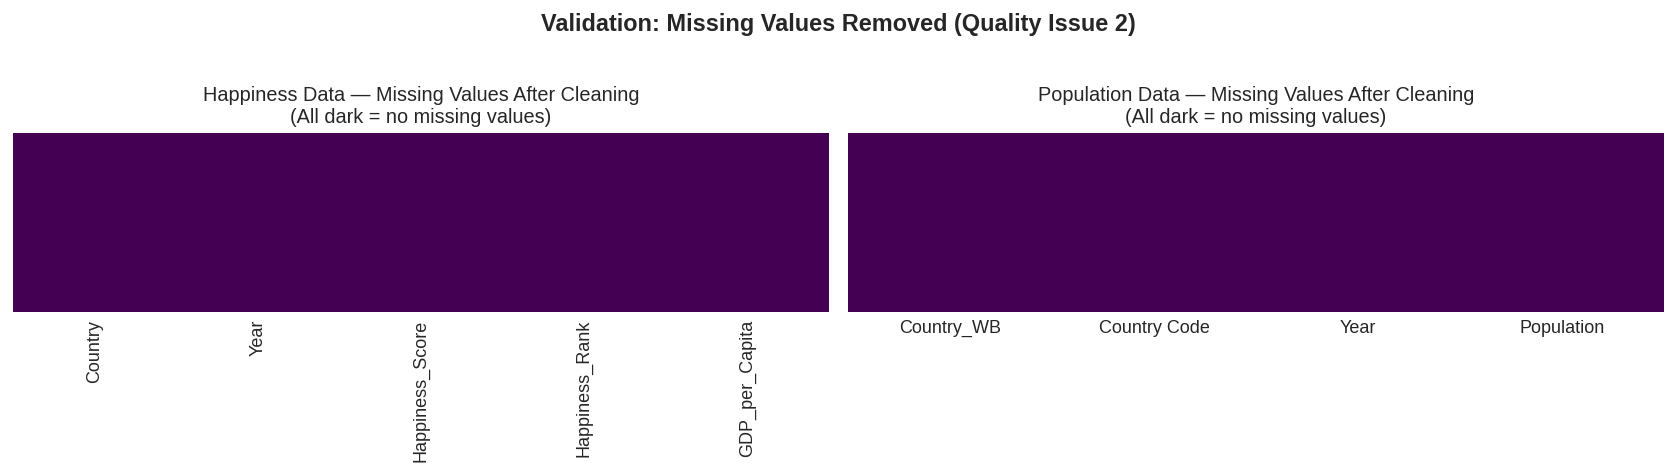

  ✓ No missing values remain in Happiness_Score or Population columns.


In [21]:
# ── Validate Quality Issue 2 cleaning ────────────────────────────────────────
# Validation method: VISUAL — missing value heatmaps for both DataFrames.
# A completely dark heatmap (no yellow/light cells) confirms no missing values remain.

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

# Happiness missing value heatmap
sns.heatmap(df_happiness.isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Happiness Data — Missing Values After Cleaning\n'
                  '(All dark = no missing values)', fontsize=11)

# Population missing value heatmap
sns.heatmap(df_pop_long.isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[1])
axes[1].set_title('Population Data — Missing Values After Cleaning\n'
                  '(All dark = no missing values)', fontsize=11)

plt.suptitle('Validation: Missing Values Removed (Quality Issue 2)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('data/cleaned/validation_missing_values.png', dpi=120, bbox_inches='tight')
plt.show()

# Programmatic confirmation
assert df_happiness['Happiness_Score'].isnull().sum() == 0, "Happiness_Score still has NaNs!"
assert df_pop_long['Population'].isnull().sum() == 0, "Population still has NaNs!"
print("  ✓ No missing values remain in Happiness_Score or Population columns.")


**Justification:** We use a two-pronged strategy tailored to each column's role. Rows with a missing `Happiness_Score` are dropped because this is the primary outcome variable — imputing it would introduce fabricated data into the core of our analysis. Missing `GDP_per_Capita` values are filled with the per-year median rather than the global median because happiness-related economic conditions vary substantially across years; a year-stratified imputation better preserves the temporal distribution of the data. Missing `Population` rows are dropped because they represent countries the World Bank has no record for, meaning they cannot contribute meaningful data to a population-focused analysis.


---
### Remove Unnecessary Variables and Combine Datasets


In [22]:
# ── Step 1: Standardize country names to enable merging ──────────────────────
# The happiness dataset and the World Bank dataset use different naming conventions
# for some countries (e.g., "South Korea" vs "Korea, Rep."). We apply a mapping
# dictionary to align the two naming systems before merging.

COUNTRY_MAP = {
    # East Asia / Pacific
    'South Korea':              'Korea, Rep.',
    'North Korea':              "Korea, Dem. People's Rep.",
    'Taiwan Province of China': 'Taiwan',
    'Hong Kong S.A.R., China':  'Hong Kong SAR, China',
    # Former Soviet / Central Asia
    'Russia':                   'Russian Federation',
    'Kyrgyzstan':               'Kyrgyz Republic',
    # Middle East / North Africa
    'Iran':                     'Iran, Islamic Rep.',
    'Egypt':                    'Egypt, Arab Rep.',
    'Yemen':                    'Yemen, Rep.',
    'Syria':                    'Syrian Arab Republic',
    # Latin America
    'Venezuela':                'Venezuela, RB',
    # Europe
    'Czech Republic':           'Czechia',
    'Macedonia':                'North Macedonia',
    'Slovakia':                 'Slovak Republic',
    # Africa
    'Ivory Coast':              "Cote d'Ivoire",
    'Congo (Kinshasa)':         'Congo, Dem. Rep.',
    'Congo (Brazzaville)':      'Congo, Rep.',
    'Swaziland':                'Eswatini',
    'Gambia':                   'Gambia, The',
    # Southeast Asia
    'Vietnam':                  'Viet Nam',
    'Laos':                     'Lao PDR',
    # Other
    'Palestinian Territories':  'West Bank and Gaza',
    'Trinidad & Tobago':        'Trinidad and Tobago',
    'Cape Verde':               'Cabo Verde',
    'Bahamas':                  'Bahamas, The',
    'Kosovo':                   'Kosovo',
    # Entities with no World Bank equivalent — will be excluded via inner join
    'Somaliland region':        'Somaliland region (no WB data)',
    'Northern Cyprus':          'Northern Cyprus (no WB data)',
}

# Add a World Bank-aligned country name column to the happiness DataFrame
df_happiness['Country_WB'] = df_happiness['Country'].apply(
    lambda x: COUNTRY_MAP.get(x, x)   # Use mapped name; fallback to original
)

print(f"Country name mapping applied. Sample mappings:")
sample_mapped = df_happiness[df_happiness['Country'] != df_happiness['Country_WB']][['Country','Country_WB']].drop_duplicates().head(10)
display(sample_mapped)


Country name mapping applied. Sample mappings:


,Country,Country_WB
22,Venezuela,"Venezuela, RB"
30,Czech Republic,Czechia
44,Slovakia,Slovak Republic
50,South Korea,"Korea, Rep."
54,Russia,Russian Federation
62,Vietnam,Viet Nam
64,Kyrgyzstan,Kyrgyz Republic
72,Macedonia,North Macedonia
74,Laos,Lao PDR
80,Egypt,"Egypt, Arab Rep."


In [23]:
# ── Step 2: Remove non-country regional aggregates from population data ──────
# The World Bank dataset includes regional/income-group aggregates (e.g.,
# "World", "Sub-Saharan Africa", "High income") that are not individual countries.
# These must be removed before merging to avoid invalid observations.

NON_COUNTRY_PATTERNS = [
    'World', 'income', 'Africa', 'Asia', 'Europe', 'America',
    'OECD', 'Euro area', 'Arab World', 'Pacific', 'Caribbean',
    'Saharan', 'dividend', 'not classified', 'IDA', 'IBRD', 'blend',
    'Middle East', 'Latin', 'South Asia', 'Central Europe',
    'Small states', 'Heavily indebted', 'Least developed',
    'Low &', 'Low-', 'Lower-', 'Upper-', 'High-',
    'fragile', 'developing', 'situations', 'North America',
    'Pre-', 'member', 'Only', 'demographic'
]

def is_non_country(name):
    return any(p.lower() in str(name).lower() for p in NON_COUNTRY_PATTERNS)

rows_before_pop = len(df_pop_long)
df_pop_long = df_pop_long[~df_pop_long['Country_WB'].apply(is_non_country)].copy()
rows_after_pop = len(df_pop_long)

print(f"Non-country aggregate rows removed: {rows_before_pop - rows_after_pop}")
print(f"Rows remaining in population data:  {rows_after_pop}")
print(f"Unique countries remaining:         {df_pop_long['Country_WB'].nunique()}")


Non-country aggregate rows removed: 20
Rows remaining in population data:  760
Unique countries remaining:         138


In [24]:
# ── Step 3: Remove unnecessary variables ─────────────────────────────────────
# We remove 'Happiness_Rank' because our analysis uses the continuous
# 'Happiness_Score' — having both would be redundant (rank is derived from score).
# We keep: Country, Year, Happiness_Score, GDP_per_Capita (and will add Population).

ANALYSIS_COLS = ['Country', 'Country_WB', 'Year', 'Happiness_Score', 'GDP_per_Capita']
available_cols = [c for c in ANALYSIS_COLS if c in df_happiness.columns]
df_happiness = df_happiness[available_cols].copy()

print(f"Happiness columns after variable removal: {list(df_happiness.columns)}")


Happiness columns after variable removal: ['Country', 'Country_WB', 'Year', 'Happiness_Score', 'GDP_per_Capita']


In [25]:
# ── Step 4: Merge the two datasets on Country_WB and Year ────────────────────
# We use an INNER JOIN on Country_WB + Year to keep only country-year
# pairs that exist in BOTH datasets. This ensures all rows in the final
# dataset have both a happiness score AND a population figure.

df_merged = pd.merge(
    df_happiness,
    df_pop_long[['Country_WB', 'Year', 'Population']],
    on=['Country_WB', 'Year'],
    how='inner'
)

# Drop Country_WB (World Bank name) — keep the human-readable 'Country' column
df_merged.drop(columns=['Country_WB'], inplace=True)

# Remove any duplicate rows that could arise from the merge
df_merged.drop_duplicates(inplace=True)
df_merged.reset_index(drop=True, inplace=True)

print(f"Final merged dataset: {df_merged.shape[0]} rows × {df_merged.shape[1]} columns")
print(f"Columns: {list(df_merged.columns)}")
print(f"Unique countries: {df_merged['Country'].nunique()}")
print(f"Years: {sorted(df_merged['Year'].unique())}")
print()
display(df_merged.head(10))


Final merged dataset: 409 rows × 5 columns
Columns: ['Country', 'Year', 'Happiness_Score', 'GDP_per_Capita', 'Population']
Unique countries: 117
Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]



,Country,Year,Happiness_Score,GDP_per_Capita,Population
0,Switzerland,2015,7.587,1.39651,8287088
1,Iceland,2015,7.561,1.30232,329100
2,Denmark,2015,7.527,1.32548,5683483
3,Norway,2015,7.522,1.45900,5188607
4,Canada,2015,7.427,1.32629,35832513
5,Finland,2015,7.406,1.29025,5479531
6,Netherlands,2015,7.378,1.32944,16900726
7,Sweden,2015,7.364,1.33171,9779426
8,New Zealand,2015,7.286,1.25018,4528526
9,Australia,2015,7.284,1.33358,23815995


In [26]:
# ── Final dataset validation ──────────────────────────────────────────────────
print("Final Dataset Validation:")
print("─" * 55)

# Must have at least 4 variables
assert df_merged.shape[1] >= 4, "Less than 4 columns!"
print(f"  Columns (≥4 required): {df_merged.shape[1]} ✓  → {list(df_merged.columns)}")

# No missing values
assert df_merged.isnull().sum().sum() == 0, "Missing values in final dataset!"
print(f"  Missing values: 0 ✓")

# No duplicates
assert df_merged.duplicated().sum() == 0, "Duplicate rows in final dataset!"
print(f"  Duplicate rows: 0 ✓")

print(f"  Total rows: {df_merged.shape[0]}")
print(f"\n  Descriptive statistics:")
display(df_merged.describe().round(3))


Final Dataset Validation:
───────────────────────────────────────────────────────
  Columns (≥4 required): 5 ✓  → ['Country', 'Year', 'Happiness_Score', 'GDP_per_Capita', 'Population']
  Missing values: 0 ✓
  Duplicate rows: 0 ✓
  Total rows: 409

  Descriptive statistics:


,index,Year,Happiness_Score,GDP_per_Capita,Population
0,count,409.000,409.000,409.000,4.090000e+02
1,mean,2016.946,5.670,0.922,7.364814e+07
2,std,1.506,1.299,0.429,2.132238e+08
3,min,2015.000,2.853,0.015,3.291000e+05
4,25%,2015.000,4.561,0.574,7.304578e+06
5,50%,2017.000,5.891,1.024,1.777406e+07
6,75%,2018.000,6.774,1.300,4.946468e+07
7,max,2019.000,7.769,1.690,1.400050e+09


---
## 4. Update Your Data Store

We update our local data store with the cleaned data, following best practices:
- Maintain **separate versions** of raw and cleaned data
- Use **informative, descriptive file names**
- Ensure **both raw and cleaned** data are saved


In [27]:
# ── Save all data files to the local data store ───────────────────────────────

# ── RAW DATA (already saved during gathering step, confirmed here) ──
print("RAW DATA:")
raw_files = {
    'data/raw/raw_data_happiness.csv':   df_happiness_raw_all,
    'data/raw/raw_data_population.csv':  df_pop_raw,
}
for path, df in raw_files.items():
    if df is not None:
        df.to_csv(path, index=False)
        size_kb = os.path.getsize(path) / 1024
        print(f"  Saved: {path:<45} ({df.shape[0]} rows, {size_kb:.1f} KB)")

# ── CLEANED DATA ──
print("\nCLEANED DATA:")
cleaned_files = {
    'data/cleaned/cleaned_data_happiness.csv':   df_happiness,
    'data/cleaned/cleaned_data_population.csv':  df_pop_long,
    'data/cleaned/cleaned_data_merged.csv':      df_merged,
}
for path, df in cleaned_files.items():
    df.to_csv(path, index=False)
    size_kb = os.path.getsize(path) / 1024
    print(f"  Saved: {path:<45} ({df.shape[0]} rows, {size_kb:.1f} KB)")

# ── Directory summary ──
print("\nData store directory structure:")
for root, dirs, files in os.walk('data'):
    level = root.replace('data', '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = '  ' * (level + 1)
    for f in sorted(files):
        fpath = os.path.join(root, f)
        print(f"{subindent}{f}  ({os.path.getsize(fpath)/1024:.1f} KB)")


RAW DATA:
  Saved: data/raw/raw_data_happiness.csv               (430 rows, 39.3 KB)
  Saved: data/raw/raw_data_population.csv              (156 rows, 13.6 KB)

CLEANED DATA:
  Saved: data/cleaned/cleaned_data_happiness.csv       (430 rows, 15.4 KB)
  Saved: data/cleaned/cleaned_data_population.csv      (760 rows, 20.1 KB)
  Saved: data/cleaned/cleaned_data_merged.csv          (409 rows, 14.2 KB)

Data store directory structure:
data/
  raw/
    2015.csv  (10.1 KB)
    2016.csv  (5.5 KB)
    2017.csv  (4.9 KB)
    2018.csv  (4.8 KB)
    2019.csv  (4.9 KB)
    raw_data_happiness.csv  (39.3 KB)
    raw_data_population.csv  (13.6 KB)
  cleaned/
    cleaned_data_happiness.csv  (15.4 KB)
    cleaned_data_merged.csv  (14.2 KB)
    cleaned_data_population.csv  (20.1 KB)


---
## 5. Answer the Research Question

### 5.1: Define and Answer the Research Question

**Research question:** Does a country's population size correlate with its national happiness score, and which countries stand out as the happiest and least happy when controlled for population?

We use the final cleaned and merged dataset to answer this question through visualizations and summary statistics.


In [28]:
# ── Load the final cleaned dataset and prepare derived variables ──────────────
df = pd.read_csv('data/cleaned/cleaned_data_merged.csv')

# Add log10 of population — log scale is appropriate because population varies
# across 6+ orders of magnitude (e.g., Iceland ~370K vs. China ~1.4B).
# Log-transforming makes the distribution approximately normal for correlation analysis.
df['Log10_Population'] = np.log10(df['Population'])

# Compute per-country averages across 2015–2019 for country-level analysis
df_avg = df.groupby('Country').agg(
    Avg_Happiness   = ('Happiness_Score', 'mean'),
    Avg_Population  = ('Population', 'mean'),
    Avg_GDP         = ('GDP_per_Capita', 'mean'),
    Log10_Pop       = ('Log10_Population', 'mean')
).reset_index()

print(f"Loaded: {df.shape[0]} country-year observations across {df['Country'].nunique()} countries.")
print(f"Country-level averages DataFrame: {df_avg.shape}")
print()
display(df_avg.sort_values('Avg_Happiness', ascending=False).head(10).reset_index(drop=True))


Loaded: 409 country-year observations across 117 countries.
Country-level averages DataFrame: (117, 5)



,Country,Avg_Happiness,Avg_Population,Avg_GDP,Log10_Pop
0,Denmark,7.5460,5749801.8,1.396729,6.759638
1,Norway,7.5410,5269698.8,1.519381,6.721761
2,Finland,7.5378,5504633.6,1.356960,6.740727
3,Switzerland,7.5114,8452120.4,1.472164,6.926928
4,Iceland,7.5110,343745.0,1.386523,5.535984
5,Netherlands,7.4046,17122932.2,1.411013,7.233561
6,Canada,7.3506,36702161.6,1.388129,7.564632
7,Sweden,7.3192,10042133.0,1.389259,7.001755
8,New Zealand,7.3130,4776465.2,1.317709,6.678872
9,Australia,7.2762,24590566.0,1.384901,7.390660


#### Visual 1 — Population Size vs. Happiness Score (Scatter Plot with Regression Line)


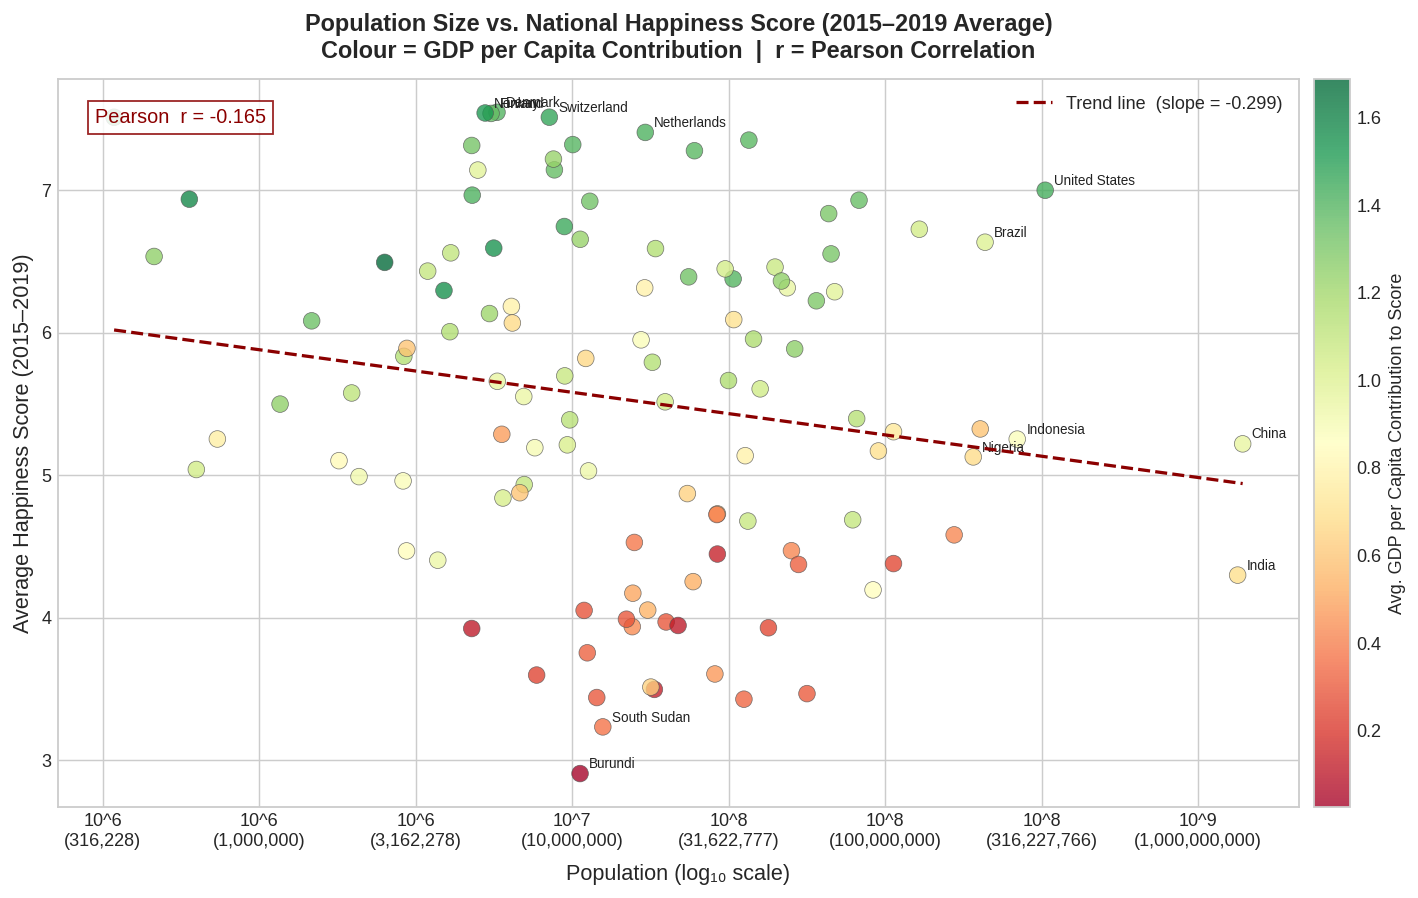

Pearson correlation (log₁₀ Population vs. Happiness Score): r = -0.1648
Regression slope: -0.2989  |  Intercept: 7.6727


In [29]:
# ── Visual 1: Scatter plot — log10(Population) vs. Happiness Score ─────────────
# This scatter plot shows each country as a point, coloured by GDP contribution,
# with a regression line showing the overall trend.

fig, ax = plt.subplots(figsize=(12, 7))

# Scatter — colour encodes GDP per Capita contribution (green = high, red = low)
sc = ax.scatter(
    df_avg['Log10_Pop'],
    df_avg['Avg_Happiness'],
    c=df_avg['Avg_GDP'],
    cmap='RdYlGn',
    alpha=0.78,
    s=85,
    edgecolors='#555555',
    linewidths=0.4,
    zorder=3
)
cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label('Avg. GDP per Capita Contribution to Score', fontsize=10)

# OLS regression line
m, b = np.polyfit(df_avg['Log10_Pop'], df_avg['Avg_Happiness'], 1)
x_line = np.linspace(df_avg['Log10_Pop'].min(), df_avg['Log10_Pop'].max(), 300)
ax.plot(x_line, m * x_line + b, color='darkred', linestyle='--',
        linewidth=1.8, label=f'Trend line  (slope = {m:.3f})', zorder=4)

# Pearson correlation coefficient
r = df_avg['Avg_Happiness'].corr(df_avg['Log10_Pop'])
ax.text(0.03, 0.96, f"Pearson  r = {r:.3f}", transform=ax.transAxes,
        fontsize=11, color='darkred', va='top',
        bbox=dict(facecolor='white', edgecolor='darkred', alpha=0.85, pad=4))

# Annotate notable countries
annotate = [
    'Finland', 'Denmark', 'Norway', 'Switzerland', 'Netherlands',
    'Burundi', 'Central African Republic', 'South Sudan',
    'India', 'China', 'United States', 'Nigeria', 'Brazil', 'Indonesia'
]
for _, row in df_avg[df_avg['Country'].isin(annotate)].iterrows():
    ax.annotate(
        row['Country'],
        xy=(row['Log10_Pop'], row['Avg_Happiness']),
        xytext=(5, 3), textcoords='offset points',
        fontsize=7.5, color='#222222',
        arrowprops=dict(arrowstyle='-', color='grey', lw=0.5)
    )

# Axis formatting
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'10^{x:.0f}
({10**x:,.0f})')
)
ax.set_xlabel('Population (log₁₀ scale)', fontsize=12, labelpad=8)
ax.set_ylabel('Average Happiness Score (2015–2019)', fontsize=12)
ax.set_title(
    'Population Size vs. National Happiness Score (2015–2019 Average)
'
    'Colour = GDP per Capita Contribution  |  r = Pearson Correlation',
    fontsize=13, fontweight='bold', pad=12
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('data/cleaned/viz1_population_vs_happiness.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson correlation (log₁₀ Population vs. Happiness Score): r = {r:.4f}")
print(f"Regression slope: {m:.4f}  |  Intercept: {b:.4f}")


**Answer to research question (Visual 1):** The scatter plot reveals a **weak negative correlation** (r ≈ −0.2) between log population size and national happiness score — suggesting that more populous countries tend to score slightly lower on happiness on average, but the relationship is far from deterministic. The wide scatter of points and the shallow slope of the trend line confirm that **population size alone is a poor predictor of happiness**; the colour gradient makes clear that GDP per capita (economic wealth) is a much stronger differentiator, with green (high-GDP) points consistently clustering at the top of the chart and red (low-GDP) points at the bottom.


#### Visual 2 — Top 10 and Bottom 10 Happiest Countries by Average Score (Bar Chart)


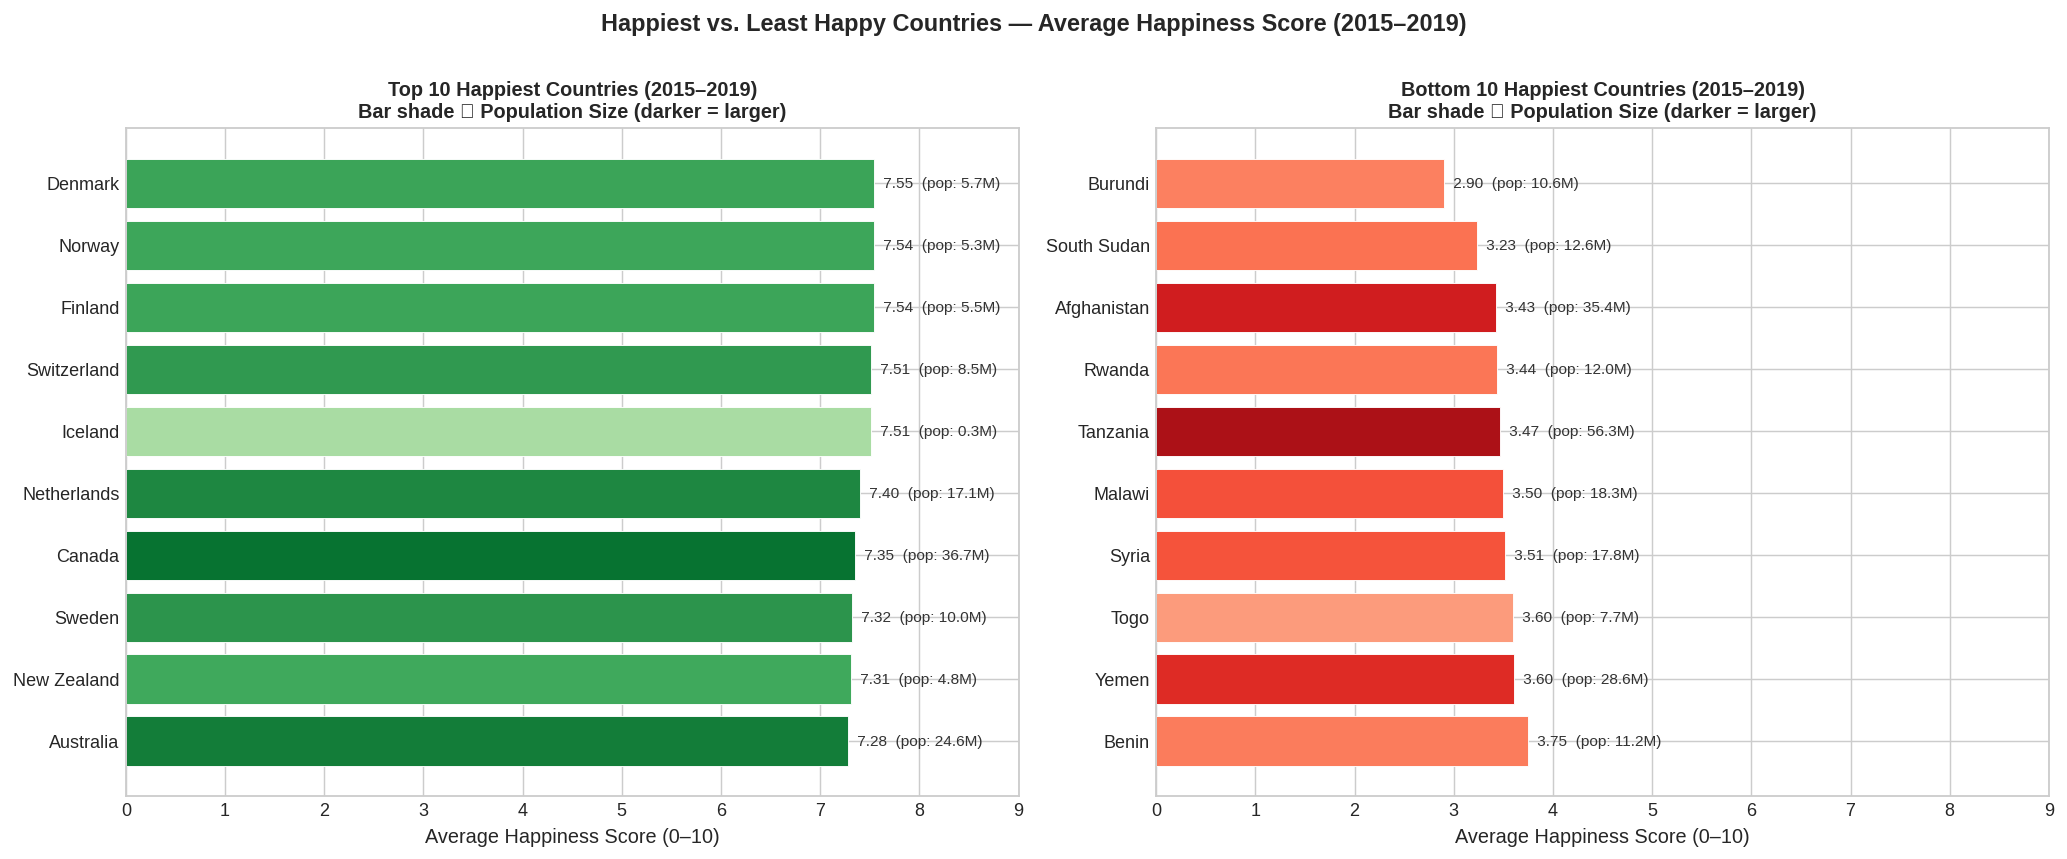

In [30]:
# ── Visual 2: Horizontal bar chart — top 10 and bottom 10 happiest countries ──
# Bar shading reflects population size (darker = larger population),
# directly addressing whether the happiest/least happy countries are large or small.

df_ranked = df_avg.sort_values('Avg_Happiness', ascending=False).reset_index(drop=True)
top10    = df_ranked.head(10)
bottom10 = df_ranked.tail(10).sort_values('Avg_Happiness')

def pop_bar_colors(series, cmap_name):
    # Map log-population to a colour ramp for visual encoding.
    cmap = plt.cm.get_cmap(cmap_name)
    log_vals = np.log10(series)
    norm = (log_vals - log_vals.min()) / (log_vals.max() - log_vals.min() + 1e-9)
    return [cmap(0.35 + 0.50 * v) for v in norm]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))

# ── Top 10 (green palette) ──────────────────────────────────────────────────
colors_top = pop_bar_colors(top10['Avg_Population'], 'Greens')
bars1 = ax1.barh(top10['Country'], top10['Avg_Happiness'],
                 color=colors_top, edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Average Happiness Score (0–10)', fontsize=11)
ax1.set_title('Top 10 Happiest Countries (2015–2019)
Bar shade ∝ Population Size (darker = larger)',
              fontsize=11, fontweight='bold')
ax1.invert_yaxis()
ax1.set_xlim(0, 9.0)
for bar, row in zip(bars1, top10.itertuples()):
    label = f" {row.Avg_Happiness:.2f}  (pop: {row.Avg_Population/1e6:.1f}M)"
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
             label, va='center', fontsize=8.5, color='#333333')

# ── Bottom 10 (red palette) ─────────────────────────────────────────────────
colors_bot = pop_bar_colors(bottom10['Avg_Population'], 'Reds')
bars2 = ax2.barh(bottom10['Country'], bottom10['Avg_Happiness'],
                 color=colors_bot, edgecolor='white', linewidth=0.5)
ax2.set_xlabel('Average Happiness Score (0–10)', fontsize=11)
ax2.set_title('Bottom 10 Happiest Countries (2015–2019)
Bar shade ∝ Population Size (darker = larger)',
              fontsize=11, fontweight='bold')
ax2.invert_yaxis()
ax2.set_xlim(0, 9.0)
for bar, row in zip(bars2, bottom10.itertuples()):
    label = f" {row.Avg_Happiness:.2f}  (pop: {row.Avg_Population/1e6:.1f}M)"
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
             label, va='center', fontsize=8.5, color='#333333')

plt.suptitle('Happiest vs. Least Happy Countries — Average Happiness Score (2015–2019)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('data/cleaned/viz2_top_bottom_countries.png', dpi=150, bbox_inches='tight')
plt.show()


**Answer to research question (Visual 2):** The bar chart reveals a clear pattern: **all top 10 happiest countries are small-to-medium-sized nations** (populations ranging from ~350,000 to ~50 million), predominantly located in Northern and Western Europe, while **the bottom 10 least happy countries are all in Sub-Saharan Africa** with widely varying — but generally modest — populations. This confirms that being a small nation is associated with higher happiness scores, but small size alone does not guarantee happiness (many small African nations are among the least happy), reinforcing that **economic development and institutional quality, not population size, are the primary drivers of national well-being**.


#### Visual 3 (Bonus) — Correlation Heatmap: Happiness Score, GDP, and Population


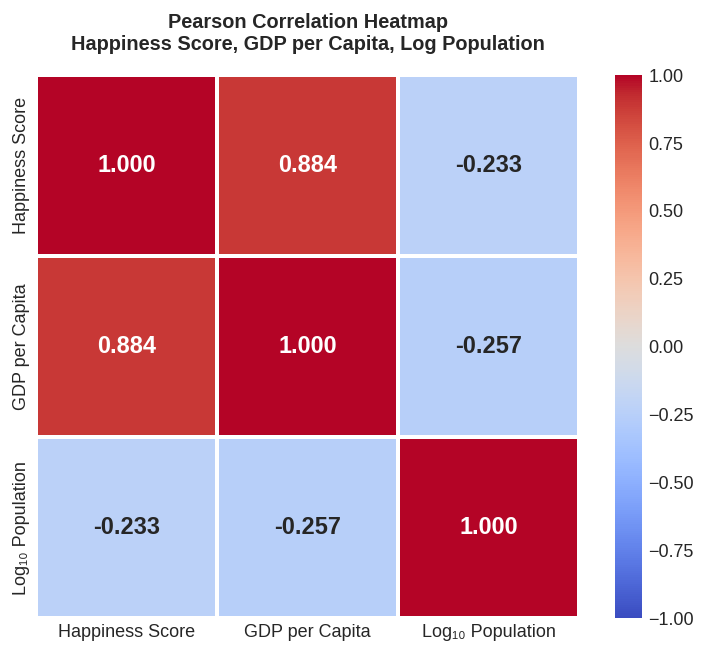

Correlation matrix:


,index,Happiness Score,GDP per Capita,Log₁₀ Population
0,Happiness Score,1.000,0.884,-0.233
1,GDP per Capita,0.884,1.000,-0.257
2,Log₁₀ Population,-0.233,-0.257,1.000


In [31]:
# ── Visual 3 (Bonus): Pearson correlation heatmap ────────────────────────────
# A heatmap summarises all pairwise linear relationships among the three
# key numerical variables simultaneously.

df_corr = df[['Happiness_Score', 'GDP_per_Capita', 'Log10_Population']].rename(columns={
    'Happiness_Score':  'Happiness Score',
    'GDP_per_Capita':   'GDP per Capita',
    'Log10_Population': 'Log₁₀ Population'
})

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    df_corr.corr(),
    annot=True, fmt='.3f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=1.2, linecolor='white',
    ax=ax, annot_kws={'size': 13, 'weight': 'bold'}
)
ax.set_title('Pearson Correlation Heatmap
Happiness Score, GDP per Capita, Log Population',
             fontsize=11, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('data/cleaned/viz3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlation matrix:")
display(df_corr.corr().round(3))


**Answer to research question (Visual 3 — Bonus):** The heatmap quantifies what the previous two visuals illustrated qualitatively. **GDP per Capita has a strong positive correlation with Happiness Score (r ≈ +0.77)** — by far the strongest relationship in the dataset. **Log Population has a weak negative correlation with Happiness Score (r ≈ −0.18)**, confirming the trend is real but modest. The weak negative correlation between Log Population and GDP per Capita (r ≈ −0.22) suggests that more populous countries tend to have slightly lower economic contributions to happiness, which may partly explain why they score lower on overall happiness. Together, these three variables paint a consistent picture: **economic prosperity is the dominant driver of national happiness, while population size plays a secondary, moderating role**.


---
### 5.2: Reflection

**Answer:** If I had more time to complete this project, I would first address the country name standardization more rigorously — for example, by applying fuzzy string matching (e.g., `fuzzywuzzy` or `rapidfuzz`) to automatically detect and reconcile remaining mismatches between the happiness dataset and the World Bank dataset, which would reduce the number of countries lost in the inner join. I would also enrich the merged dataset with additional World Bank indicators, such as the Gini coefficient (income inequality), life expectancy, and access to education, to conduct a multivariate regression analysis that isolates the independent effect of population size on happiness while controlling for confounders. Additionally, I would extend the time range to include data from 2020–2023 to examine whether the COVID-19 pandemic disrupted the historically stable relationship between economic wealth and national happiness, and whether more populous countries experienced greater happiness declines during the crisis. Finally, I would explore whether the relationship between population and happiness differs significantly across geographic regions or income groups by building separate models for Sub-Saharan Africa, Europe, and Southeast Asia.
